### Time to get your hands dirty! Planning a telescope observation

*(exam guidelines available [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/exams.md))*

Let's build your first Markov Chain! 

You are a real astronomer (not a theory guy like me) and are planning an expensive observational campaign. You want to know how likely it is that tomorrow night will be clear given the weather tonight (clear or cloudy). The key piece of information here is that the weather tomorrow depends on the weather today. From past history, you know that:

$$p({\rm clear \; tomorrow} \, |\,  {\rm cloudy \; today}) = 0.5,$$

which means that

$$p({\rm cloudy \; tomorrow} \, |\, {\rm cloudy \; today}) = 0.5.$$

We also have

$$p({\rm cloudy \; tomorrow} \, |\, {\rm clear \; today}) = 0.1,$$

which means that

$$p({\rm clear \; tomorrow} \, |\, {\rm clear \; today}) = 0.9.$$


- We can start with the sky conditions today and make predictions going forward more and more into the future.
- This will look like a big decision tree. 
- After enough days, we'll reach equilibrium probabilities that have to do with the mean weather statistics (ignoring seasons) and we'll arrive at

$$p({\rm clear}) = 0.83,$$

and 

$$p({\rm cloudy}) = 0.17.$$

You get the same answer for day $N$ as day $N+1$ and it doesn't matter whether it was clear or cloudy on the day that you started. The steps that we have taken in this process are, indeed, a **MARKOV CHAIN**.

Here is an illustration of this process:

![image.png](https://miro.medium.com/max/416/1*frksGjINf5oTjx7WL81U3w.png)

#### Tasks

- Start off on a cloud day. 
- Implement your weather forecast based on the above probabilities
- Run your simulator for N days (with $N\gtrsim 10^4$)
- Prepare a plot with the number of days on the x axis and the cumulative fraction of, say, sunny days over the number of days so far on the y axis. This is called a **trace-plot**, showing how our estimate of $p(\mathrm{clear})$ evolves as the chain samples.  
- Prepare a histogram of the above plot. This reveals the distribution of $p(\mathrm{clear})$.
- Use a summary statistics to determine the most likely value and an error on our estimate.

**Important:** 
- In MCMC the process must be **stationary** which basically means that the chain statistics look the same no matter which chunk you look at, e.g. first half, second half, or every other point, etc.  
- Obviously that isn't going to be the case in the early steps of the chain. In our example above, after some time the process was stationary, but not in the first few days.
- So, there is a **burn-in** phase that needs to be discarded. How one determines the number of early steps to discard as burn-in is tricky, but ***you should always start with a traceplot of your samples!***


#### Tasks

- In the above example, experiment with chopping off different numbers of initial points as burn-in.


#### (Optional, not examinable) Finance

- Redo the same for the Markovian process describing the stock market (see above in this notebook). If you've written your code well, this should require minor modifications.

- For instance, the stock market has phases of growing prices (bull), dreasing prices (bear) and recession. This would a a Marov Chain model:

<div style="background-color: white; padding: 10px; display: inline-block;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/95/Finance_Markov_chain_example_state_space.svg/400px-Finance_Markov_chain_example_state_space.svg.png" alt="Markov Chain Diagram">
</div>

In [4]:
# Execute this cell
import numpy as np
from scipy import stats
import pylab as plt
import astroML.stats
from tqdm.notebook import tqdm

In [16]:
#NOTE:
#Cloudy = 0
#Clear = 1

#implementing a matrix with transitions probabilities as in the image
p_from_0 = np.array([[0.5], [0.5]])
p_from_1 = np.array([[0.1], [0.9]])

transition_matrix = np.vstack((p_from_0.T, p_from_1.T))

print(transition_matrix)
print(transition_matrix[1,1])
print(p_from_1[0])


[[0.5 0.5]
 [0.1 0.9]]
0.9
[0.1]


In [47]:
#LET'S DEFINE A FUNCTION THAT IMPLEMENTS AND EVOLVES OUR MARKOV CHAIN
def markov_chain():

    meteo = [0] #starting from a cloudy day

    for k in tqdm(range(1,10000)):
        rng = np.random.rand()
        #forecasting
        if meteo[k-1] == 1:
            if rng <= p_from_1[0]:
                meteo.append(0)
            else: 
                meteo.append(1)
        elif meteo[k-1] == 0:
            if rng <= p_from_0[0]:
                meteo.append(0)
            else: 
                meteo.append(1)
        else:
            raise ValueError

    meteo = np.array(meteo)
    #let's return the cumsum (cumulative sum) of the sunny days divided by the number of days up to that point, in order to obtain a 
    #"trace plot" of the sunny days, which gives us a look at how the p(1) (prob of a clear day) evolves as we evolve the chain

    #chain length ( how many days )
    length = meteo.shape[0]
    #index array +1 not to have a division by 0, index_array will be [0,1,2,3,4,...length] up to the days length. so +1 is just [1,2,3...]
    index_array = np.arange(length) + 1
    trace_clear = np.cumsum(meteo)/index_array
    trace_cloudy = np.cumsum(meteo == 0)/index_array

    
    return trace_clear, trace_cloudy, meteo

trace_clear, trace_cloudy, meteo = markov_chain()

  0%|          | 0/9999 [00:00<?, ?it/s]

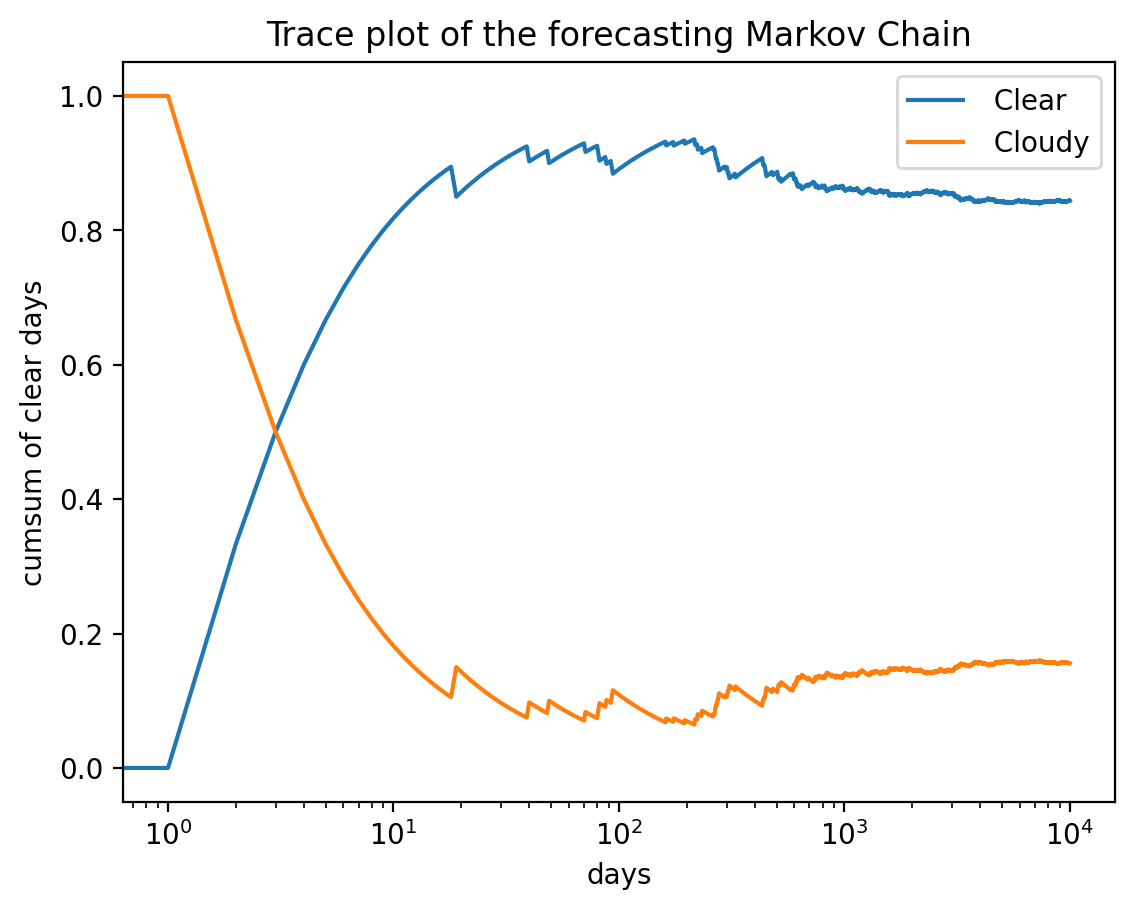

In [53]:
#This plot really is a "trace" of how much our Markov Chain is converging onto the right value
plt.plot(trace_clear, label=' Clear')
plt.plot(trace_cloudy, label=' Cloudy')
plt.xscale('log')
plt.xlabel("days")
plt.ylabel("cumsum of clear days")
plt.title("Trace plot of the forecasting Markov Chain")
plt.legend()

Text(0.5, 1.0, 'probability distribution of a clear day')

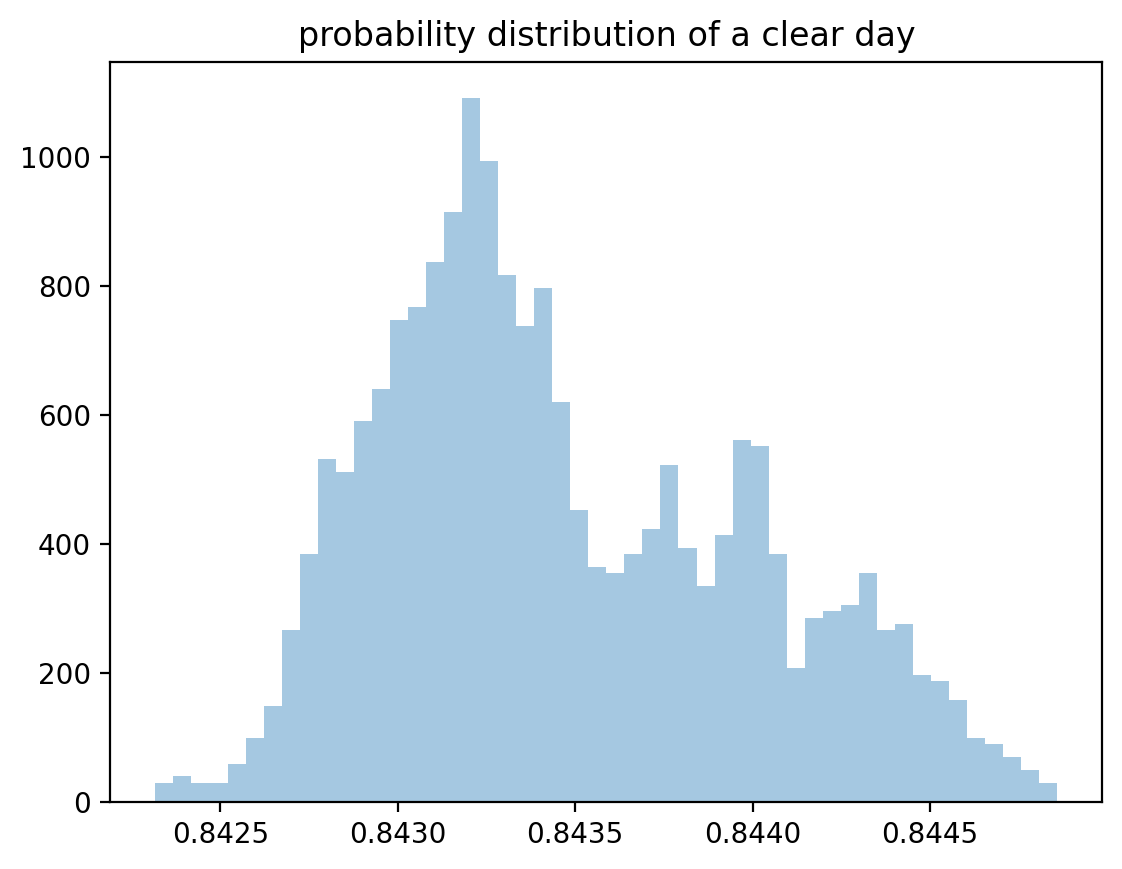

In [61]:
#To plot the hist we check at the trace plot and choose a burn-in or "thermalization length" for our chain
burn_in = 2000
trace_clear = trace_clear[burn_in:]
plt.hist(trace_clear, bins=50, density=True, alpha=0.4);
plt.title("probability distribution of a clear day")

In [63]:

print(np.median(trace_clear))
print(astroML.stats.sigmaG(trace_clear))
print(min(trace_clear),max(trace_clear))


0.8433545770574377
0.000580553746244963
0.8423167848699764 0.8448587570621469


#### (Optional, not examinable) Finance

- Redo the same for the Markovian process describing the stock market (see above in this notebook). If you've written your code well, this should require minor modifications.

- For instance, the stock market has phases of growing prices (bull), dreasing prices (bear) and recession. This would a a Marov Chain model:

<div style="background-color: white; padding: 10px; display: inline-block;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/95/Finance_Markov_chain_example_state_space.svg/400px-Finance_Markov_chain_example_state_space.svg.png" alt="Markov Chain Diagram">
</div>

In [65]:
#NOTE:
#BULL = 0 (GROWING PRICES)
#BEAR = 1 (DECREASING PRICES)
#STAGNANT = 2 (RECESSION)


#implementing a matrix with transitions probabilities as in the image
p_from_0 = np.array([[0.9], [0.075], [0.025]])
p_from_1 = np.array([[0.15], [0.8], [0.05]])
p_from_2 = np.array([[0.25], [0.25], [0.5]])

transition_matrix = np.vstack((p_from_0.T, p_from_1.T, p_from_2.T))

print(transition_matrix)


[[0.9   0.075 0.025]
 [0.15  0.8   0.05 ]
 [0.25  0.25  0.5  ]]


In [124]:
#LET'S DEFINE A FUNCTION THAT IMPLEMENTS AND EVOLVES OUR MARKOV CHAIN
def markov_chain():

    stack = [2] #starting from a BULL state

    for k in tqdm(range(1,10000)):
        rng = np.random.rand()
        #forecasting
        if stack[k-1] == 0:
            if rng <= p_from_0[0]:
                stack.append(0)
            elif rng > p_from_0[0] and rng <= (p_from_0[1] + p_from_0[0]):
                stack.append(1)                
            else: 
                stack.append(2)
                
        elif stack[k-1] == 1:
            if rng <= p_from_1[0]:
                stack.append(0)
            elif rng > p_from_1[0] and rng <= (p_from_1[1] + p_from_1[0]):
                stack.append(1)                
            else: 
                stack.append(2)

        elif stack[k-1] == 2:
            if rng <= p_from_2[0]:
                stack.append(0)
            elif rng > p_from_2[0] and rng <= (p_from_2[1] + p_from_2[0]):
                stack.append(1)                
            else: 
                stack.append(2)
        
        else:
            raise ValueError

    stack = np.array(stack)
    #let's return the cumsum (cumulative sum) of the sunny days divided by the number of days up to that point, in order to obtain a 
    #"trace plot" of the sunny days, which gives us a look at how the p(1) (prob of a clear day) evolves as we evolve the chain

    #chain length ( how many days )
    length = stack.shape[0]
    #index array +1 not to have a division by 0, index_array will be [0,1,2,3,4,...length] up to the days length. so +1 is just [1,2,3...]
    index_array = np.arange(length) + 1
    trace_bull = np.cumsum(stack == 0)/index_array
    trace_bear = np.cumsum(stack == 1)/index_array
    trace_recession = np.cumsum(stack == 2)/index_array
    
    return trace_bull, trace_bear, trace_recession, stack

trace_bull, trace_bear, trace_recession, stack = markov_chain()

  0%|          | 0/9999 [00:00<?, ?it/s]

[1.         1.         0.66666667 ... 0.06441288 0.06440644 0.0645    ]


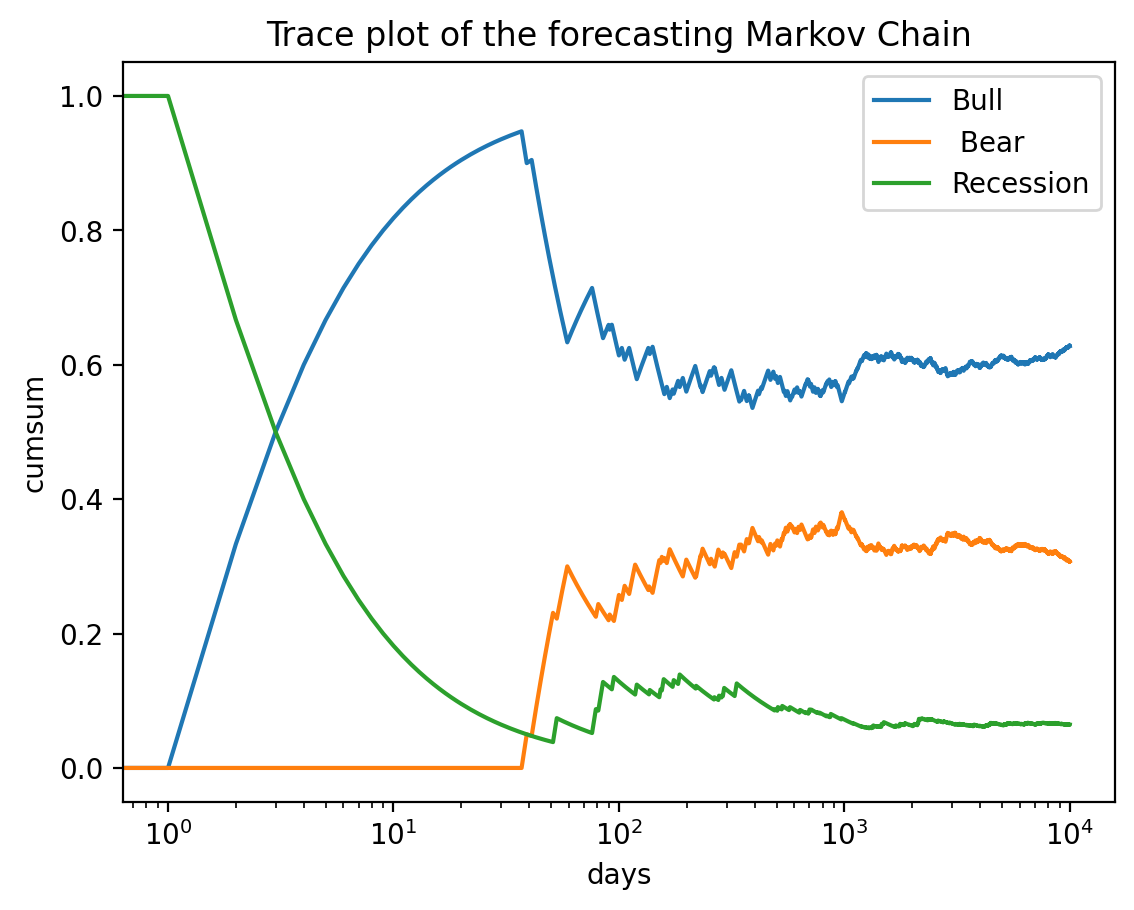

In [125]:
#This plot really is a "trace" of how much our Markov Chain is converging onto the right value
plt.plot(trace_bull, label='Bull')
plt.plot(trace_bear, label=' Bear')
plt.plot(trace_recession, label='Recession')
print(trace_recession)
plt.xscale('log')
plt.xlabel("days")
plt.ylabel("cumsum")
plt.title("Trace plot of the forecasting Markov Chain")
plt.legend()

Text(0.5, 1.0, 'probability distribution')

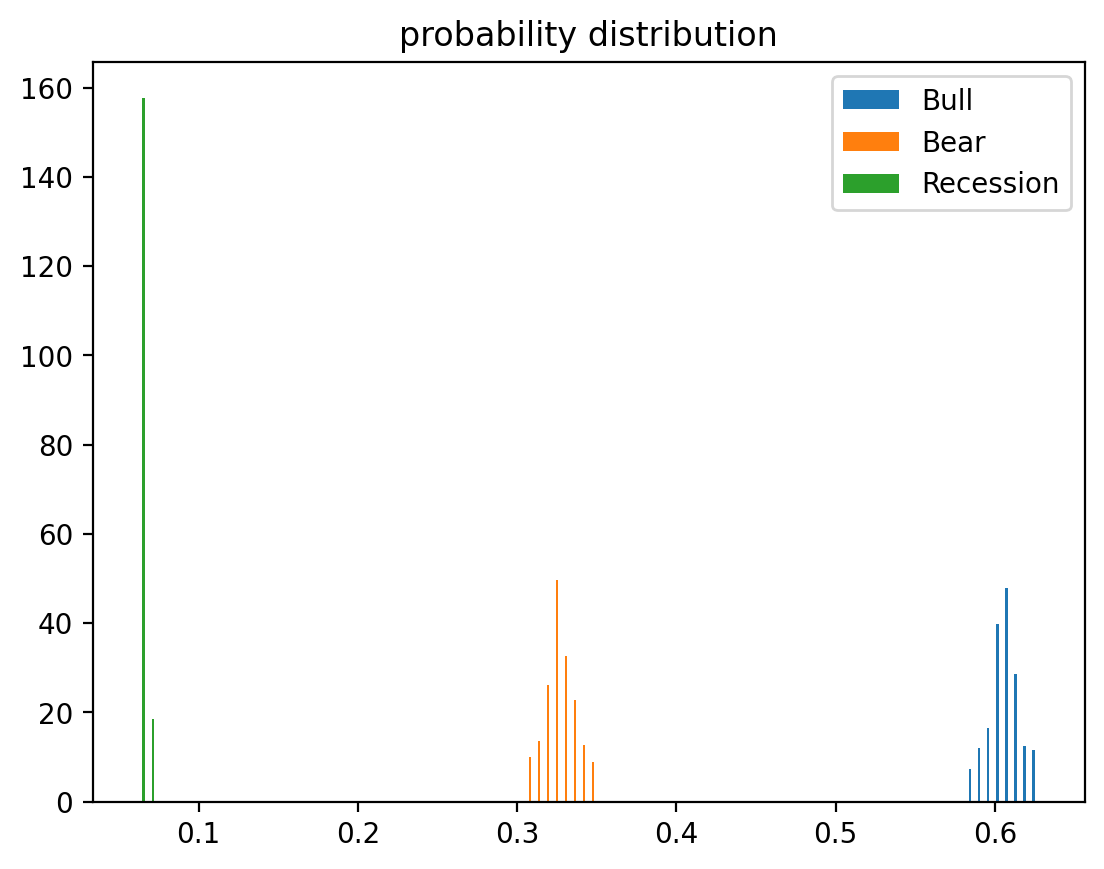

In [126]:
#To plot the hist we check at the trace plot and choose a burn-in or "thermalization length" for our chain
burn_in = 2500
stack = stack[burn_in:]
trace_bull = trace_bull[burn_in:]
trace_bear = trace_bear[burn_in:]
trace_recession = trace_recession[burn_in:]
trace = np.hstack((trace_bull, trace_bear, trace_recession))
plt.hist([trace_bull, trace_bear, trace_recession], bins=100, label=['Bull', 'Bear', 'Recession'], density = True);
plt.legend()
plt.title("probability distribution")

Text(0.5, 1.0, 'Probabilità')

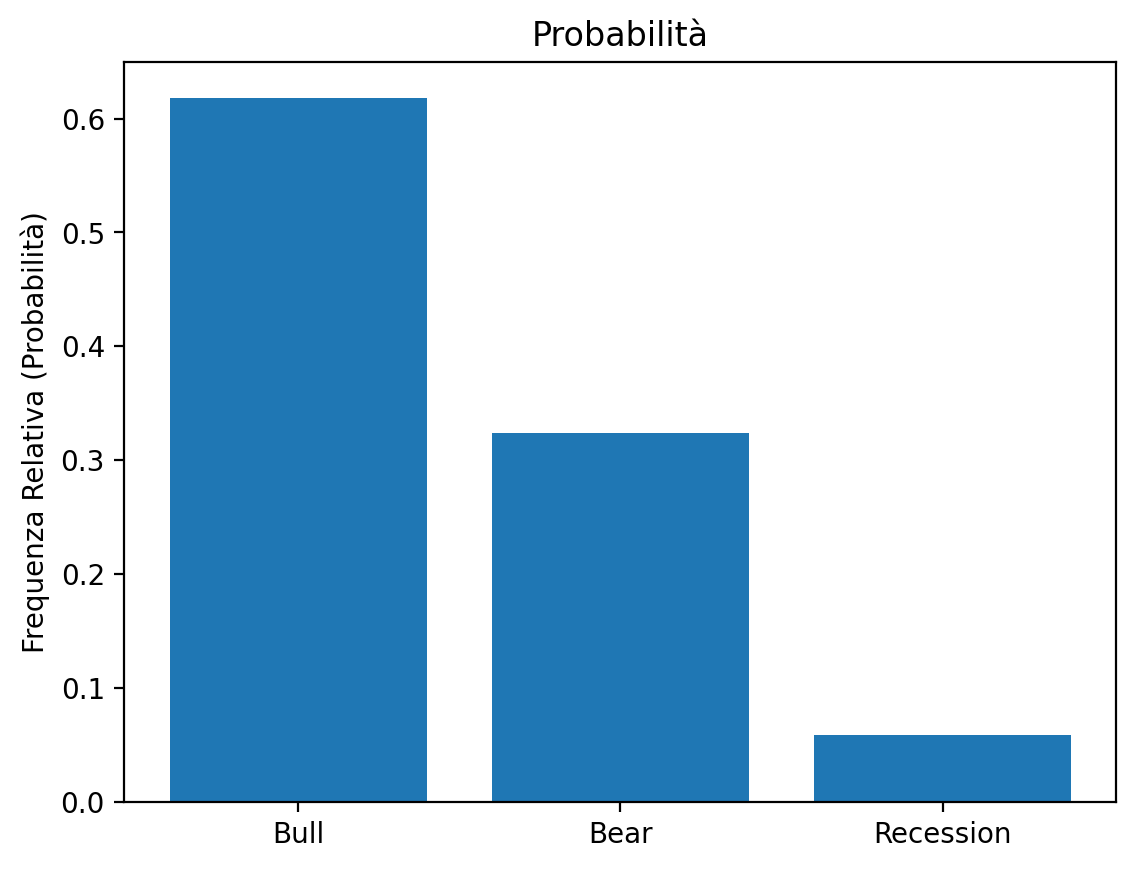

In [120]:
pesi = np.ones_like(stack) / len(stack)
plt.hist(stack, bins=[-0.5, 0.5, 1.5, 2.5], weights=pesi, rwidth=0.8)
plt.ylabel('Frequenza Relativa (Probabilità)')
plt.xticks([0, 1, 2], ['Bull', 'Bear', 'Recession'])
plt.title("Probabilità")